# E-Commerce Data Analysis Project
### Tools: Python | Pandas | Seaborn | Matplotlib

## Step 1: Importing Libraries and Loading Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Professional_Ecommerce_Data_Project1.csv")
df.head()

,Order_ID,Order_Date,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Payment_Method
0,ORD-2024-10000,2023-10-26,Rajshahi,Fashion,Women Clothing,4740.41,4,0.14,634.85,Bank Transfer
1,ORD-2024-10001,2022-04-29,Khulna,Computing,Storage,4717.10,4,0.04,751.57,Bank Transfer
2,ORD-2024-10002,2022-08-31,Chittagong,Computing,Storage,3767.49,4,0.04,925.64,Cash on Delivery
3,ORD-2024-10003,2022-10-20,Khulna,Computing,Storage,3761.63,2,0.03,1084.07,Mobile Banking
4,ORD-2024-10004,2022-01-30,Rajshahi,Mobile Phones,Tablet,724.09,5,0.24,187.55,Credit Card


## Step 2: Checking Missing Values, Data Types & Fixing Date Column

In [4]:
# Null value চেক
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# Date কলাম ঠিক করা
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print("\nDate column fixed:", df['Order_Date'].dtype)

Missing Values:
 Order_ID          0
Order_Date        0
Region            0
Category          0
Sub_Category      0
Sales             0
Quantity          0
Discount          0
Profit            0
Payment_Method    0
dtype: int64

Data Types:
 Order_ID           object
Order_Date         object
Region             object
Category           object
Sub_Category       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Payment_Method     object
dtype: object

Date column fixed: datetime64[ns]


## Step 3: Correlation Matrix — Sales, Discount & Profit

             Sales  Discount    Profit
Sales     1.000000 -0.001772  0.859460
Discount -0.001772  1.000000 -0.006594
Profit    0.859460 -0.006594  1.000000


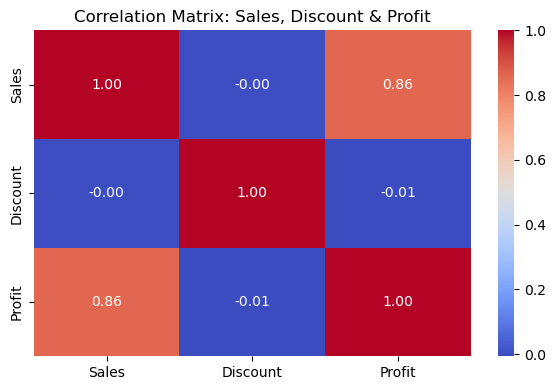

In [5]:
correlation = df[['Sales', 'Discount', 'Profit']].corr()
print(correlation)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix: Sales, Discount & Profit')
plt.tight_layout()
plt.show()

## Step 4: Customer Segmentation — Top 10 Customers by Revenue

C:\Users\piyas\AppData\Local\Temp\ipykernel_32996\1596466698.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='Order_ID', y='Total_Revenue', palette='Blues_d')


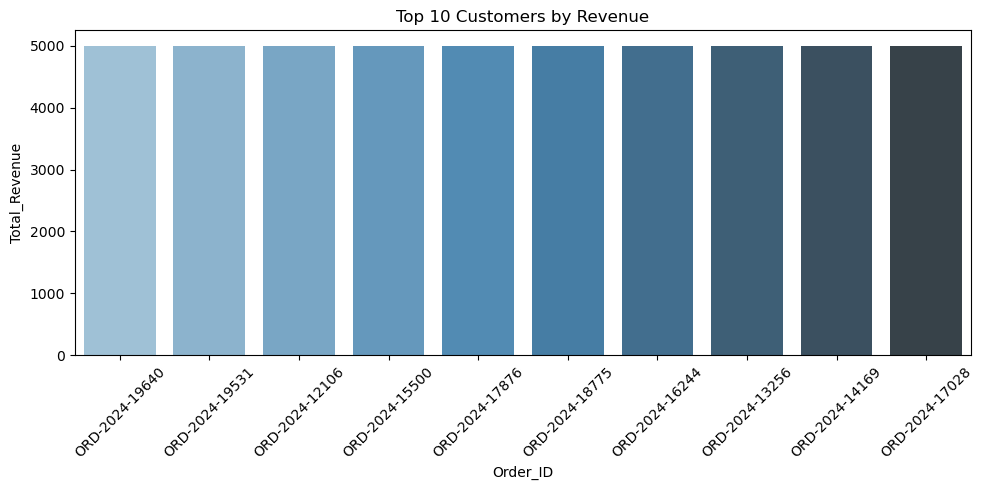

In [6]:
top_customers = df.groupby('Order_ID')['Sales'].sum()\
                  .sort_values(ascending=False).head(10).reset_index()
top_customers.columns = ['Order_ID', 'Total_Revenue']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers, x='Order_ID', y='Total_Revenue', palette='Blues_d')
plt.title('Top 10 Customers by Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 5: Distribution Analysis — Sales & Profit Histogram

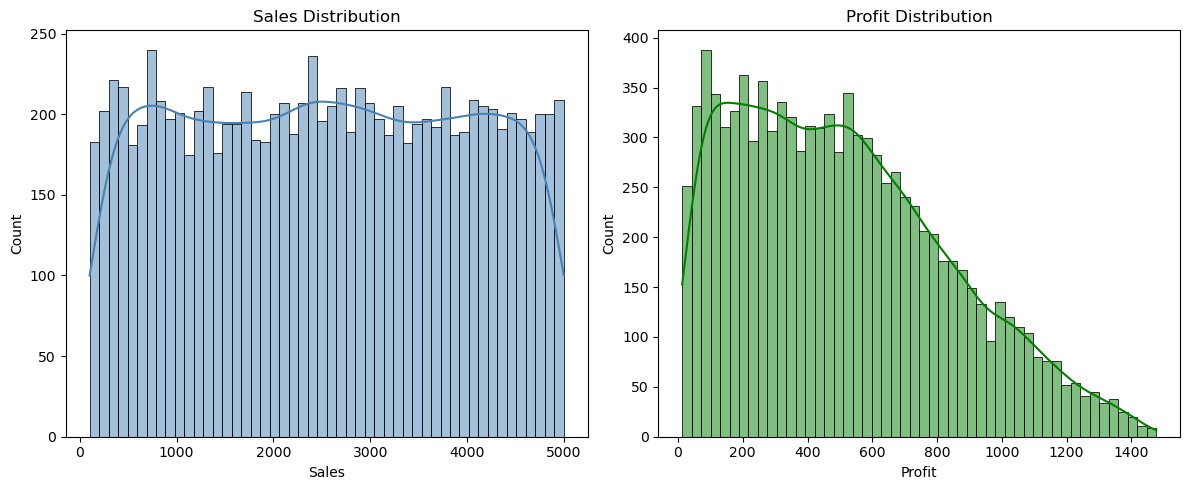

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Sales Distribution')

sns.histplot(df['Profit'], bins=50, kde=True, color='green', ax=axes[1])
axes[1].set_title('Profit Distribution')

plt.tight_layout()
plt.show()

## Step 6: Outlier Detection — Boxplot for Sales & Profit

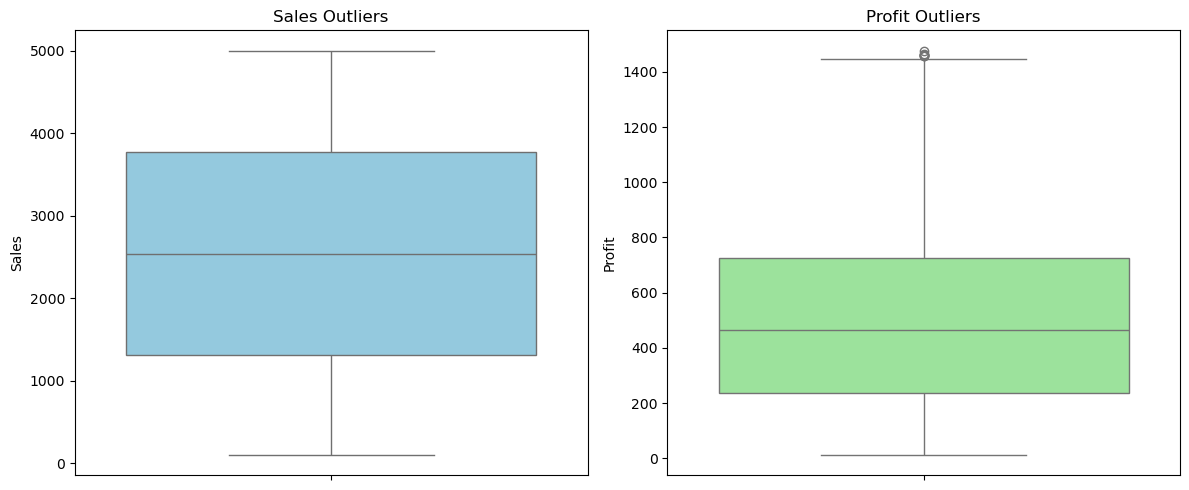

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Sales'], color='skyblue', ax=axes[0])
axes[0].set_title('Sales Outliers')

sns.boxplot(y=df['Profit'], color='lightgreen', ax=axes[1])
axes[1].set_title('Profit Outliers')

plt.tight_layout()
plt.show()